In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from trianglechain import TriangleChain

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor import architecture

from msfm.utils import files, observation, cross_statistics, power_spectra
from deep_lss.utils import configuration
from msi.utils import preprocessing, plotting

# load data

### v14

In [3]:
base_dir = "/global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended"
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v14/extended.yaml")

# young-serenity-1089 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/3g0z8qob/overview)
wl_dir = os.path.join(base_dir, "lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default")
wl_steps = 400_000

# classic-frost-1096 (https://wandb.ai/eth-cosmo/y3-deep-lss/runs/fp2vxm07/overview)
gc_dir = os.path.join(base_dir, "clustering/mutual_info/2025-05-14_23-10-45_deepsphere_default")
gc_steps = 240_000

# Cross-probe posterior predictive distribution
lensing -> clustering
$$s_{gc}^{rep} \sim p(s_{gc} | s_{wl}^{obs}) = \int d\theta p(s_{gc} | \theta, s_{wl}^{obs}) p(\theta | s_{wl}^{obs})$$
clustering -> lensing
$$s_{wl}^{rep} \sim p(s_{wl} | s_{gc}^{obs}) = \int d\theta p(s_{wl} | \theta, s_{gc}^{obs}) p(\theta | s_{gc}^{obs})$$

In [4]:
def prepare_data(model_dir, model_steps, mock_label):
    _, s_grid, theta_grid, file_dict = preprocessing.get_reshaped_network_preds(
        model_dir,
        n_steps=model_steps,
        with_fidu=False,
    )
    s_obs = file_dict[f"mocks/pred/{mock_label}"]
    theta_post = np.load(os.path.join(model_dir, f"{model_steps}_steps_likelihood_sigmoid/likelihood_flow/chain_{mock_label}.npy"))

    return s_grid, s_obs, theta_grid, theta_post


def sample_cross_probe_ppd(
    in_probe, 
    mock_label,
    train_flow=False, 
    plot_type="contour", 
    n_star=100_000,
    n_plot=1_000,
    np_seed=11
):
    rng = np.random.default_rng(np_seed)
    
    s_wl_grid, s_wl_obs, theta_wl_grid, theta_wl_post = prepare_data(wl_dir, wl_steps, mock_label)
    s_gc_grid, s_gc_obs, theta_gc_grid, theta_gc_post = prepare_data(gc_dir, gc_steps, mock_label)

    assert np.all(theta_wl_grid[:,:3] == theta_gc_grid[:,:3])

    print("\n")
    if in_probe == "lensing":
        out_probe = "clustering"
        s_prior = s_gc_grid
        s_obs_ref = s_gc_obs
        
        print(f"flow = p(s_gc | theta_wl, s_wl)")
        flow_dir = gc_dir
        features = s_gc_grid
        context = np.concatenate([theta_wl_grid, s_wl_grid], axis=-1)

        print(f"post = p(theta_wl | s_wl)")
        theta_post = theta_wl_post
        s_obs = s_wl_obs
        
    if in_probe == "clustering":
        out_probe = "lensing"
        s_prior = s_wl_grid
        s_obs_ref = s_wl_obs
        
        print(f"flow = p(s_wl | theta_gc, s_gc)")
        flow_dir = wl_dir
        features = s_wl_grid
        context = np.concatenate([theta_gc_grid, s_gc_grid], axis=-1)
        
        print(f"post = p(theta_gc | s_gc)")
        theta_post = theta_gc_post
        s_obs = s_gc_obs
        
    print(f"Conditioning on {in_probe} and sampling in {out_probe} summary space")

    flow = LikelihoodFlow(
        params=[],
        conf=conf, 
        embedding_net=architecture.get_context_embedding_net(context.shape[-1]),
        base_dist=architecture.get_normal_dist(features.shape[-1]),
        transform=architecture.get_sigmoids_transform(features.shape[-1]),
        out_dir=flow_dir,
        label=f"cross_tests",
        load_existing=not train_flow,
    )

    if train_flow:
        flow.fit(
            x=features,
            theta=context,
            batch_size=10_000,
            scheduler_type="cosine",
            save_model=True,
        )

    # subsample the posterior
    i_star = rng.integers(0, theta_post.shape[0], n_star)
    theta_star = theta_post[i_star]
    
    # sample the flow
    s_obs_star = np.repeat(s_obs[np.newaxis], n_star, axis=0)
    context_star = np.concatenate([theta_star, s_obs_star], axis=-1)
    s_rep = flow.sample_likelihood(
        context_star,
        n_samples=1,
        batch_size=context_star.shape[0]//10,
    )
    s_rep = np.squeeze(s_rep)
    
    # plotting
    if in_probe == "lensing":
        prior_label = r"$p(s_{gc})$"
        post_label = r"$p(s_{gc}|s_{wl}^{obs})$"
        obs_label = r"$s_{wl}^{obs}$"
    elif in_probe == "clustering":
        prior_label = r"$p(s_{wl})$"
        post_label = r"$p(s_{wl}|s_{gc}^{obs})$"
        obs_label = r"$s_{gc}^{obs}$"

    tri = TriangleChain(show_legend=True)

    if plot_type == "contour":
        tri.contour_cl(s_prior, color="tab:blue", label=prior_label)
        tri.contour_cl(s_rep, color="tab:orange", label=post_label)
    elif plot_type == "scatter":
        scatter_kwargs = {"s": 10, "marker": "o"}
        i_rand = rng.integers(0, s_prior.shape[0], n_plot)

        tri.scatter(s_prior[i_rand], color="tab:blue", scatter_kwargs=scatter_kwargs, label=prior_label)
        tri.scatter(s_rep[i_rand], color="tab:orange", scatter_kwargs=scatter_kwargs, label=post_label)

    tri.scatter(s_obs_ref[np.newaxis], scatter_kwargs={"s": 500, "marker": "*"}, color="k", scatter_vline_1D=True, plot_histograms_1D=False, label=prior_label);


    log_prob_rep = flow.log_likelihood(
        s_rep,
        context_star,
        return_numpy=True
    )
    log_prob_obs = flow.log_likelihood(
        np.repeat(s_obs_ref[np.newaxis], context_star.shape[0], axis=0),
        context_star,
        return_numpy=True
    )
    p_val = np.mean(log_prob_obs < log_prob_rep)
    print(f"p_val = {p_val}")

    fig, ax = plt.subplots(figsize=(12,8))
    
    ax.hist(log_prob_rep, bins=100, label=r"$\log p(s_{rep} | \theta^\star$)", alpha=0.5)
    ax.hist(log_prob_obs, bins=100, label=r"$\log p(s_{obs} | \theta^\star$)", alpha=0.5)
    
    ax.legend()

26-01-29 04:04:36 input_output INF   Loading predictions from /global/cfs/cdirs/des/athomsen/deep_lss/run_files/v14/extended/lensing/mutual_info/2025-04-19_18-54-31_deepsphere_default/preds_400000.h5 
26-01-29 04:04:36 input_output INF   Array shapes: 
26-01-29 04:04:36 input_output INF   fiducial/vali/pred = (40000, 12) 
26-01-29 04:04:36 input_output INF   fiducial/vali/i_example = (40000,) 
26-01-29 04:04:36 input_output INF   fiducial/vali/i_noise = (40000,) 
26-01-29 04:04:36 input_output INF   grid/pred          = (2500, 80, 12) 
26-01-29 04:04:36 input_output INF   grid/cosmo         = (2500, 80, 6) 
26-01-29 04:04:36 input_output INF   grid/i_example     = (2500, 80) 
26-01-29 04:04:36 input_output INF   grid/i_noise       = (2500, 80) 
26-01-29 04:04:36 input_output INF   grid/i_sobol       = (2500, 80) 


26-01-29 04:04:36 preprocessin INF   Shapes after concatenation and selection: 
26-01-29 04:04:36 preprocessin INF   grid_preds  = (200000, 12) 
26-01-29 04:04:36 preprocess

/global/u2/a/athomsen/multiprobe-simulation-inference/msi/flow_conductor/likelihood_flow.py:501: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.loa

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

  0%|          | 0/91 [00:00<?, ?it/s]

p_val = 0.80043


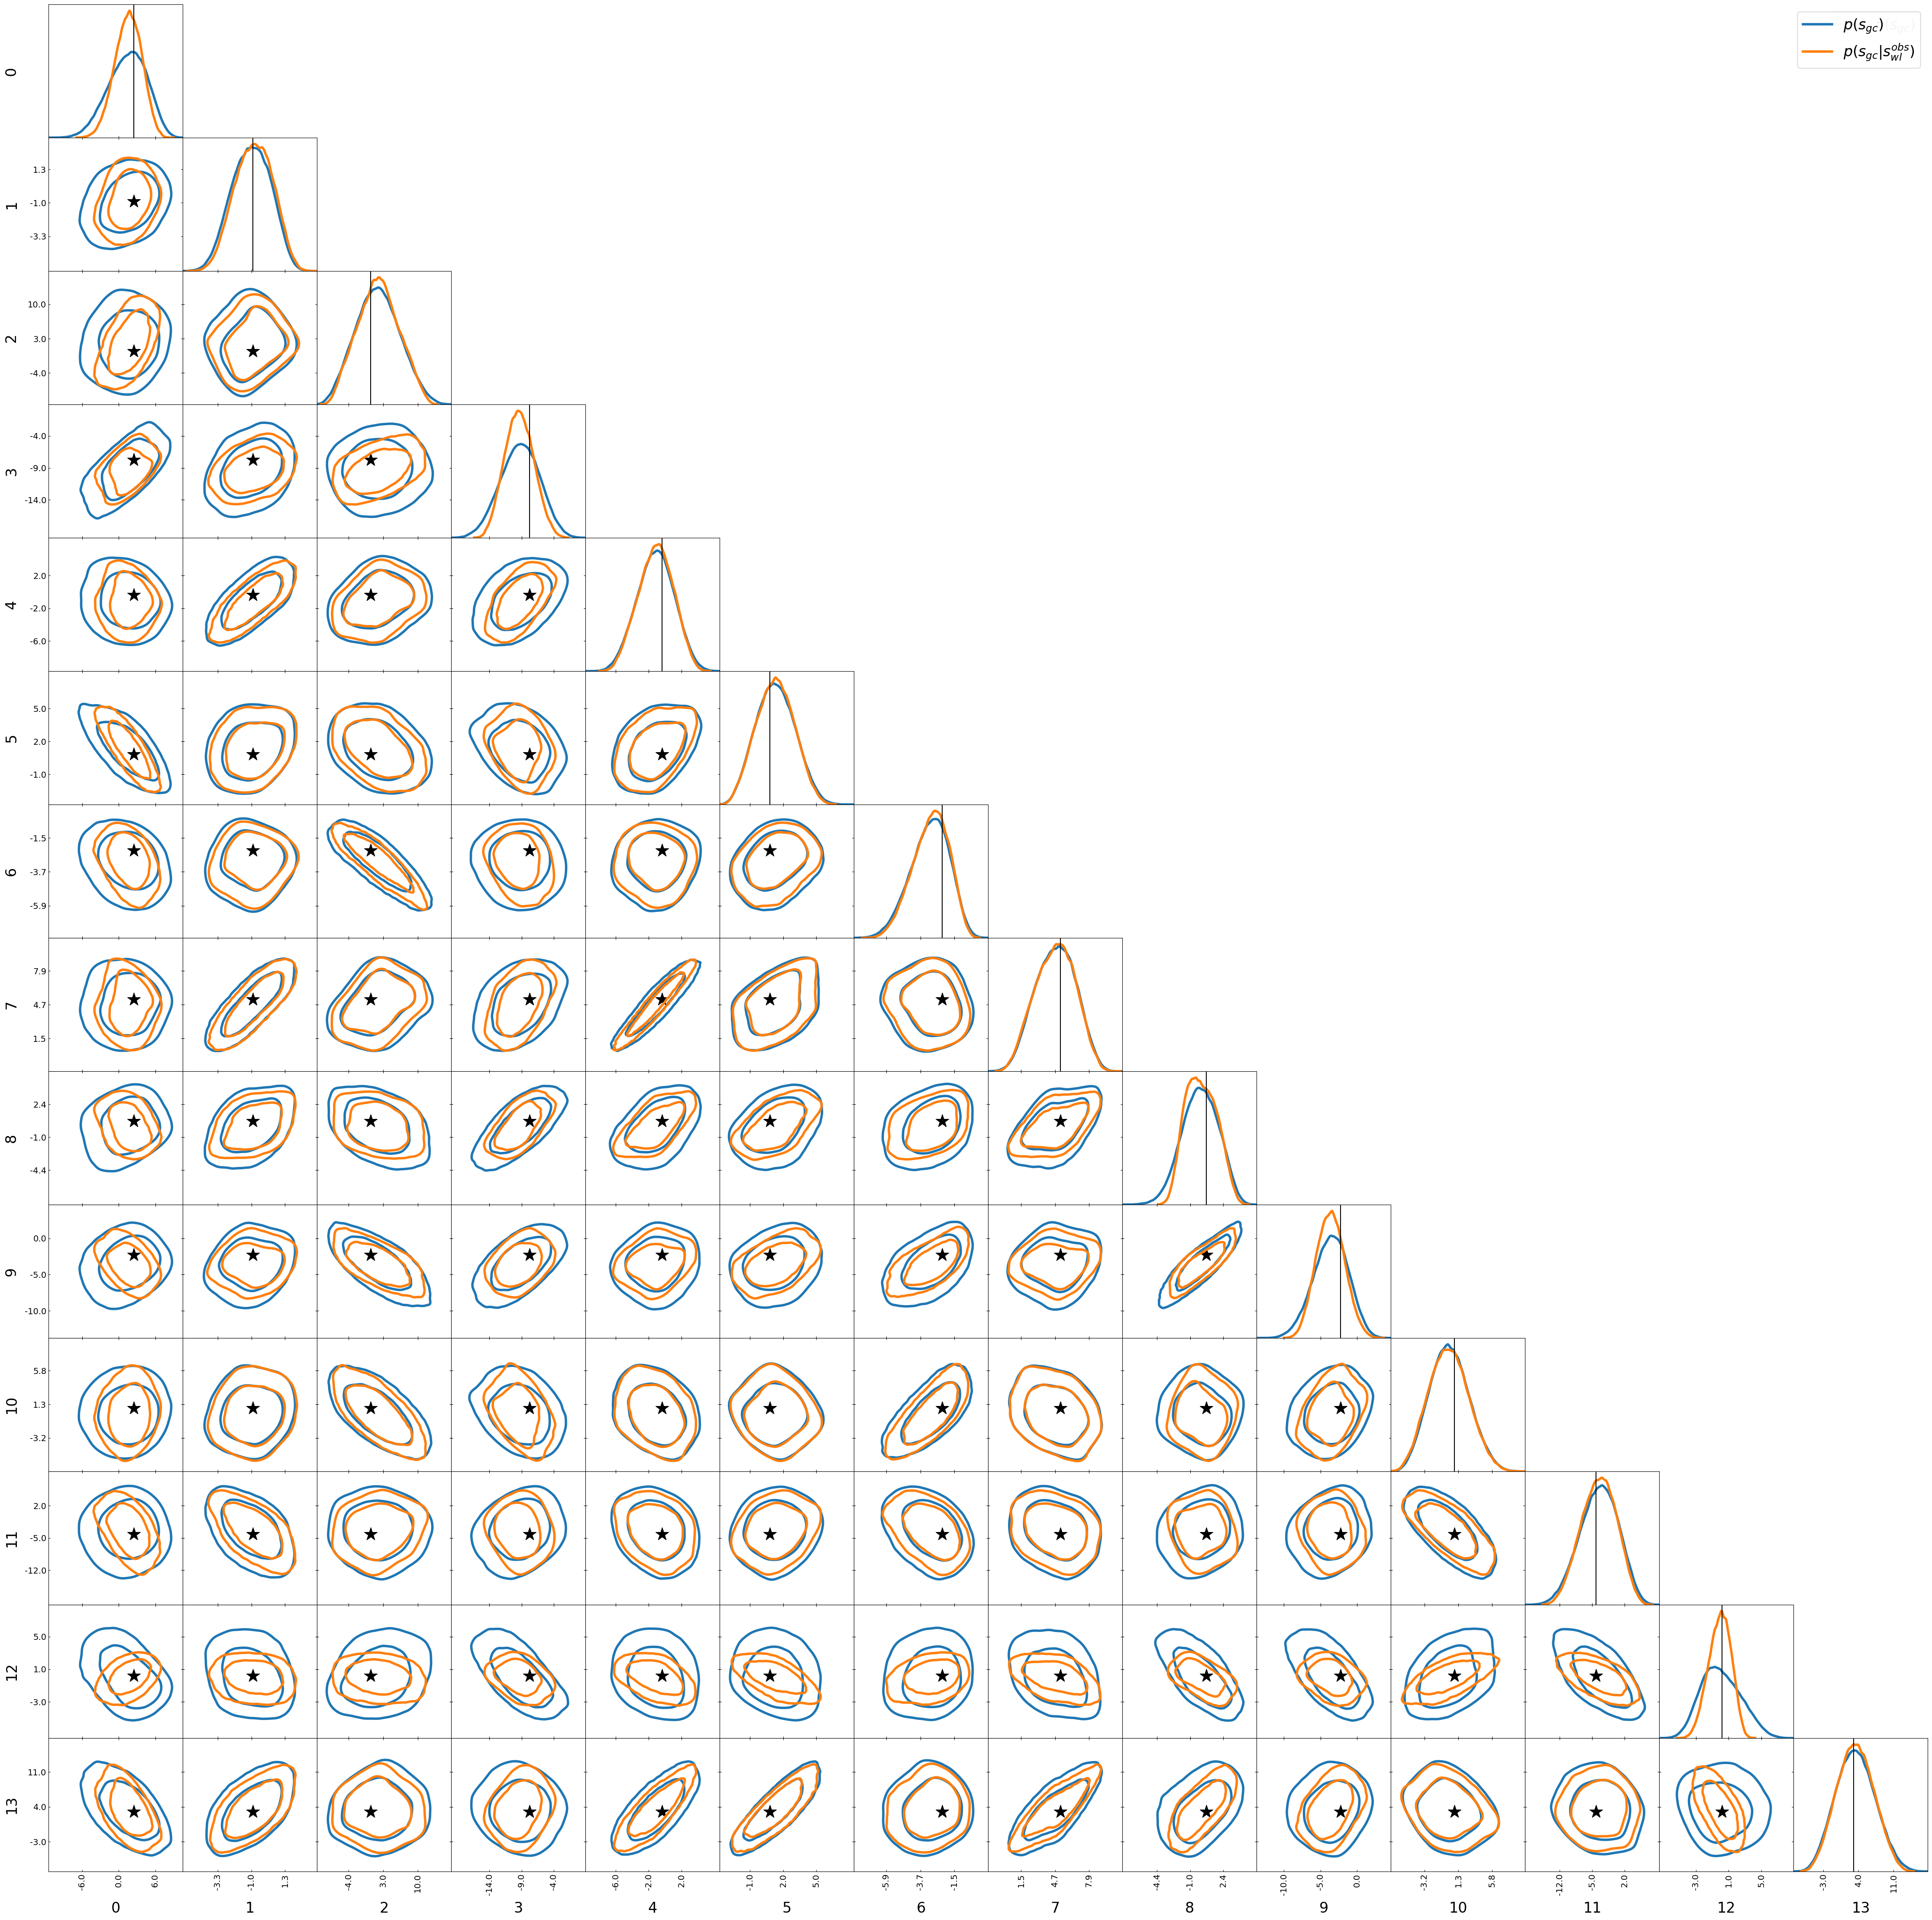

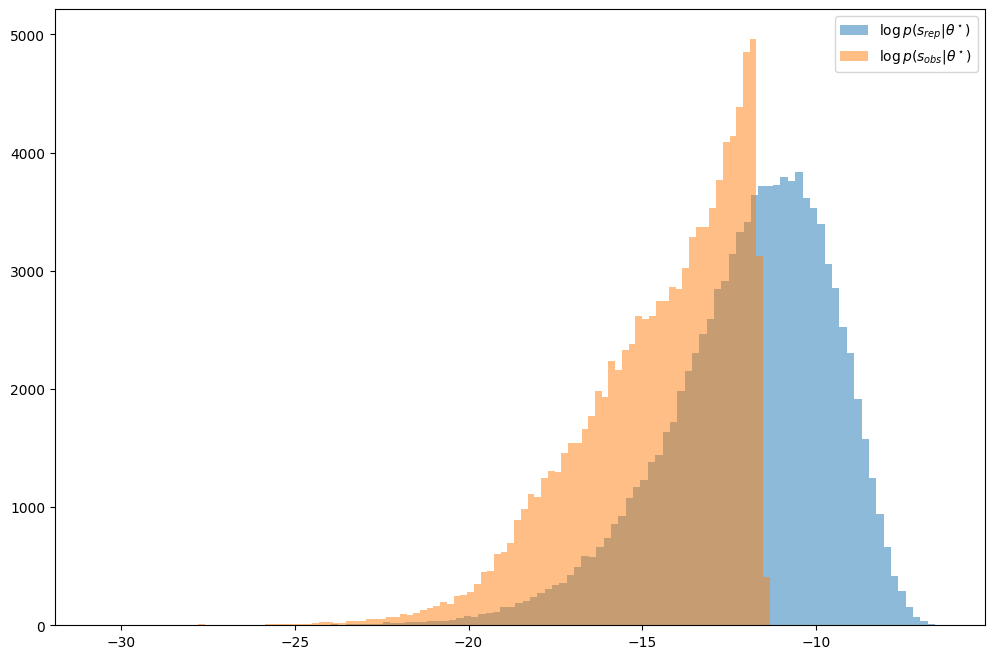

In [5]:
sample_cross_probe_ppd(
    # in_probe="clustering",
    in_probe="lensing",
    # mock_label="Buzzard_0",
    mock_label="Buzzard_3",
    train_flow=False, 
)

In [6]:
stop

NameError: name 'stop' is not defined

# dev

In [ ]:
def prepare_data(model_dir, model_steps, mock_label):
    _, s_grid, theta_grid, file_dict = preprocessing.get_reshaped_network_preds(
        model_dir,
        n_steps=model_steps,
        with_fidu=False,
    )
    s_obs = file_dict[f"mocks/pred/{mock_label}"]
    theta_post = np.load(os.path.join(model_dir, f"{model_steps}_steps_likelihood_sigmoid/likelihood_flow/chain_{mock_label}.npy"))

    return s_grid, s_obs, theta_grid, theta_post

in_probe = "lensing"
mock_label = "Buzzard_0"
# mock_label = "Buzzard_3"
train_flow = False 
plot_type = "contour" 
n_star = 100_000
n_plot = 1_000
np_seed = 11

rng = np.random.default_rng(np_seed)

s_wl_grid, s_wl_obs, theta_wl_grid, theta_wl_post = prepare_data(wl_dir, wl_steps, mock_label)
s_gc_grid, s_gc_obs, theta_gc_grid, theta_gc_post = prepare_data(gc_dir, gc_steps, mock_label)

assert np.all(theta_wl_grid[:,:3] == theta_gc_grid[:,:3])

print("\n")
if in_probe == "lensing":
    out_probe = "clustering"

    s_prior = s_gc_grid
    s_obs_ref = s_gc_obs
    
    print(f"flow = p(s_gc | theta_wl, s_wl)")
    flow_dir = gc_dir
    features = s_gc_grid
    context = np.concatenate([theta_wl_grid, s_wl_grid], axis=-1)

    print(f"post = p(theta_wl | s_wl)")
    theta_post = theta_wl_post
    s_obs = s_wl_obs
    
if in_probe == "clustering":
    out_probe = "lensing"

    s_prior = s_wl_grid
    s_obs_ref = s_wl_obs
    
    print(f"flow = p(s_wl | theta_gc, s_gc)")
    flow_dir = wl_dir
    features = s_wl_grid
    context = np.concatenate([theta_gc_grid, s_gc_grid], axis=-1)
    
    print(f"post = p(theta_gc | s_gc)")
    theta_post = theta_gc_post
    s_obs = s_gc_obs
    
print(f"Conditioning on {in_probe} and sampling in {out_probe} summary space")

flow = LikelihoodFlow(
    params=[],
    conf=conf, 
    embedding_net=architecture.get_context_embedding_net(context.shape[-1]),
    base_dist=architecture.get_normal_dist(features.shape[-1]),
    transform=architecture.get_sigmoids_transform(features.shape[-1]),
    out_dir=flow_dir,
    label=f"cross_tests",
    load_existing=not train_flow,
)

if train_flow:
    flow.fit(
        x=features,
        theta=context,
        batch_size=10_000,
        scheduler_type="cosine",
        save_model=True,
    )

# subsample the posterior
i_star = rng.integers(0, theta_post.shape[0], n_star)
theta_star = theta_post[i_star]

# sample the flow
s_obs_star = np.repeat(s_obs[np.newaxis], n_star, axis=0)
context_star = np.concatenate([theta_star, s_obs_star], axis=-1)
s_rep = flow.sample_likelihood(
    context_star,
    n_samples=1,
    batch_size=context_star.shape[0]//10,
)
s_rep = np.squeeze(s_rep)


    



In [ ]:
log_prob_rep = flow.log_likelihood(
    s_rep,
    context_star,
    return_numpy=True
)

log_prob_obs = flow.log_likelihood(
    np.repeat(s_obs_ref[np.newaxis], context_star.shape[0], axis=0),
    context_star,
    return_numpy=True
)



In [ ]:
p = np.mean(log_prob_obs < log_prob_rep)

print(p)

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.scatter(log_prob_rep, log_prob_obs)

ax.legend()

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))

ax.hist(log_prob_rep, bins=100, label=r"$\log p(s_{rep} | \theta^\star$)", alpha=0.5)
ax.hist(log_prob_obs, bins=100, label=r"$\log p(s_{obs} | \theta^\star$)", alpha=0.5)

ax.legend()